# ** About Dataset **

This dataset contains information about credit card transactions, with a focus on identifying fraudulent activity. Each record represents a single transaction and includes various features related to transaction behavior, amount, and classification.

The dataset is designed to help analyze patterns between legitimate and fraudulent transactions, making it suitable for building fraud detection models and understanding financial risk.

It can be used for:

Fraud detection and classification
Exploratory Data Analysis (EDA)
Anomaly detection
Machine learning and predictive modeling

The dataset provides a practical scenario for working with imbalanced data and developing models to detect rare fraudulent events.

[Data Source](https://www.kaggle.com/datasets/abhaypanchal/credit-fraud)


## ** Importing Libraries **

In [75]:
import matplotlib.pyplot  as plt
from sklearn import tree
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

## ** Load Data**

In [83]:
df = pd.read_csv("data/credit_fraud.csv")
df.head()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41.0,2453.81,12686.50,21.0,0.0,9.0,0.0,2438.2,5.2,0
1,49.0,1574.12,36337.02,37.0,0.0,4.0,0.0,2967.1,8.4,1
2,38.0,14897.42,23295.64,21.0,0.0,0.0,0.0,4703.6,3.7,0
3,38.0,9927.23,38586.08,46.0,0.0,17.0,0.0,4281.2,5.5,1
4,61.0,12914.13,2013.73,34.0,0.0,NaN,0.0,4366.7,9.7,1


In [84]:
df.dtypes

age                           str
transaction_amount        float64
account_balance           float64
num_transactions_today    float64
is_foreign_transaction    float64
transaction_hour          float64
prev_fraud_flag           float64
merchant_distance_km      float64
merchant_risk_score       float64
is_fraud                    int64
dtype: object

In [85]:
def checkCategories(df, column):
    display(df[column].unique())

In [86]:
checkCategories(df, 'is_fraud') 

array([0, 1])

In [87]:
df['is_fraud'].value_counts(dropna=False)

is_fraud
0    16740
1    15560
Name: count, dtype: int64

In [88]:
# encoding the dataset - an array of 0s and 1s

df['is_fraud'] = (df['is_fraud'] == 'fraud').astype(int)


In [89]:
df['is_fraud'].unique()

array([0])

In [90]:
df['is_fraud'].isna().sum()

np.int64(0)

In [92]:

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']


In [94]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


## ** Get the independent and dependent features **

In [95]:
X, y  = credit_fraud['merchant_risk_score'], credit_fraud['is_fraud']

In [96]:
len(X)

32300

In [101]:
features = list(df.columns)
features

['age',
 'transaction_amount',
 'account_balance',
 'num_transactions_today',
 'is_foreign_transaction',
 'transaction_hour',
 'prev_fraud_flag',
 'merchant_distance_km',
 'merchant_risk_score',
 'is_fraud']

In [108]:
features = list(df.columns)
features.remove('is_foreign_transaction')
features.remove('prev_fraud_flag')
features

['age',
 'transaction_amount',
 'account_balance',
 'num_transactions_today',
 'transaction_hour',
 'merchant_distance_km',
 'merchant_risk_score',
 'is_fraud']

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [114]:
model = tree.DecisionTreeClassifier(random_state=42)
model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [ ]:

X = df.drop(columns=['is_fraud'])   # DataFrame (2‑D)
y = df['is_fraud']                  # Series (1‑D)


In [118]:
# Verify  data before splitting:
type(X), X.shape
type(y), y.shape


(pandas.Series, (32300,))

In [119]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
# Verification after splitting
print(type(X_train), X_train.shape)
print(type(y_train), y_train.shape)


<class 'pandas.DataFrame'> (25840, 9)
<class 'pandas.Series'> (25840,)


In [ ]:
X_train.select_dtypes(include=['object', 'string']).columns # This will list all non‑numeric feature columns


Index(['age'], dtype='str')

In [124]:

for col in X_train.columns:
    if X_train[col].dtype == 'object':
        print(col, X_train[col].unique()[:10])


In [126]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [127]:
model = tree.DecisionTreeClassifier(random_state=42)
model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [ ]:
f

AttributeError: 'DecisionTreeClassifier' object has no attribute 'tree_'

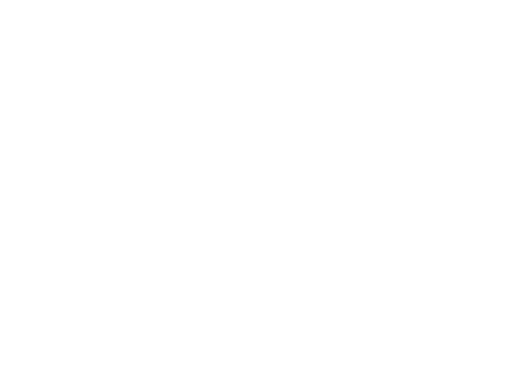

In [129]:
tree.plot_tree(model, filled=True, fontsize=12)

## ** Hyper-parameter tuning: the process of manipulating/ adjusting the values of specific paramter of a model **

## ** Fit the model **